In [15]:
# ============================================================
# CELL 1 — Imports + Dataset Discovery  [UNCHANGED]
# ============================================================

!pip install torch torchvision matplotlib scikit-learn pandas pillow tqdm --quiet

import os
import cv2
import json
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, f1_score, roc_curve, auc)

DATASET_PATH = Path("/kaggle/input/datasets/ghofranegharbi/typed-hanwritten-crops")
WORK_DIR     = Path("/kaggle/working")
DATA_DIR     = WORK_DIR / "cnn2_data"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"\nDataset path  : {DATASET_PATH}")
print(f"Path exists   : {DATASET_PATH.exists()}")

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_PATH}\n"
        "Check the Kaggle dataset name and folder structure."
    )

print("\nTop-level folders found:")
for item in sorted(DATASET_PATH.iterdir()):
    if item.is_dir():
        subfolders = [s for s in item.iterdir() if s.is_dir()]
        print(f"  {item.name}/ → {len(subfolders)} subfolders")

typed_images = []
typed_dir    = DATASET_PATH / 'typed'
if typed_dir.exists():
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']:
        typed_images.extend(list(typed_dir.rglob(ext)))
else:
    raise FileNotFoundError(f"typed/ folder not found inside {DATASET_PATH}")

handwritten_images = []
hw_dir             = DATASET_PATH / 'handwritten'
if hw_dir.exists():
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']:
        handwritten_images.extend(list(hw_dir.rglob(ext)))
else:
    raise FileNotFoundError(f"handwritten/ folder not found inside {DATASET_PATH}")

print(f"\nTyped images found       : {len(typed_images)}")
print(f"Handwritten images found : {len(handwritten_images)}")
print(f"Total                    : {len(typed_images) + len(handwritten_images)}")

print("\nTyped subfolders:")
for sub in sorted(typed_dir.iterdir()):
    if sub.is_dir():
        n = sum(len(list(sub.glob(f'*{e}')))
                for e in ['.jpg','.jpeg','.png','.JPG','.PNG'])
        print(f"  {sub.name}: {n} images")

print("\nHandwritten subfolders:")
for sub in sorted(hw_dir.iterdir()):
    if sub.is_dir():
        n = sum(len(list(sub.glob(f'*{e}')))
                for e in ['.jpg','.jpeg','.png','.JPG','.PNG'])
        print(f"  {sub.name}: {n} images")

print("\nDataset discovery complete ✅")

Device: cuda
GPU: Tesla T4

Dataset path  : /kaggle/input/datasets/ghofranegharbi/typed-hanwritten-crops
Path exists   : True

Top-level folders found:
  handwritten/ → 9 subfolders
  typed/ → 9 subfolders

Typed images found       : 10421
Handwritten images found : 9585
Total                    : 20006

Typed subfolders:
  Channels: 1158 images
  CostStructure: 1158 images
  CustomerRelationships: 1158 images
  CustomerSegments: 1158 images
  KeyActivities: 1158 images
  KeyPartners: 1158 images
  KeyResources: 1157 images
  RevenueStreams: 1158 images
  ValuePropositions: 1158 images

Handwritten subfolders:
  Channels: 1065 images
  CostStructure: 1065 images
  CustomerRelationships: 1065 images
  CustomerSegments: 1065 images
  KeyActivities: 1065 images
  KeyPartners: 1065 images
  KeyResources: 1065 images
  RevenueStreams: 1065 images
  ValuePropositions: 1065 images

Dataset discovery complete ✅


In [16]:
# ============================================================
# CELL 2 — Build Dataset  [UNCHANGED]
# ============================================================

IMG_SIZE = 224

DATA_DIR.mkdir(parents=True, exist_ok=True)
for split in ['train', 'val', 'test']:
    (DATA_DIR / split / 'typed').mkdir(parents=True, exist_ok=True)
    (DATA_DIR / split / 'handwritten').mkdir(parents=True, exist_ok=True)


def resize_and_save(src_path, dst_path, size=IMG_SIZE):
    try:
        img = Image.open(src_path).convert('RGB')
        img = img.resize((size, size), Image.LANCZOS)
        img.save(dst_path, quality=95)
        return True
    except Exception:
        return False


n_per_class  = min(len(typed_images), len(handwritten_images), 5000)
typed_sample = random.sample(typed_images,      n_per_class)
hw_sample    = random.sample(handwritten_images, n_per_class)

print(f"Using {n_per_class} images per class (balanced)")
print(f"Total dataset size: {n_per_class * 2}")


def three_way_split(images, seed=SEED):
    train, temp = train_test_split(images, test_size=0.30, random_state=seed)
    val,   test = train_test_split(temp,   test_size=0.50, random_state=seed)
    return train, val, test


typed_train, typed_val, typed_test = three_way_split(typed_sample)
hw_train,    hw_val,    hw_test    = three_way_split(hw_sample)

splits = {
    'train': (typed_train, hw_train),
    'val':   (typed_val,   hw_val),
    'test':  (typed_test,  hw_test),
}

print("\nCopying and resizing images...")
stats = {'typed': 0, 'handwritten': 0, 'failed': 0}

for split, (t_imgs, h_imgs) in splits.items():
    for cls, imgs in [('typed', t_imgs), ('handwritten', h_imgs)]:
        for i, src in enumerate(tqdm(imgs, desc=f"{split}/{cls}", leave=False)):
            dst = DATA_DIR / split / cls / f"{cls}_{split}_{i:05d}.jpg"
            if resize_and_save(src, dst):
                stats[cls] += 1
            else:
                stats['failed'] += 1

print(f"\n=== DATASET BUILT ===")
for split in ['train', 'val', 'test']:
    n_t = len(list((DATA_DIR/split/'typed').glob('*.jpg')))
    n_h = len(list((DATA_DIR/split/'handwritten').glob('*.jpg')))
    print(f"  {split:<6}: typed={n_t}  handwritten={n_h}")
print(f"  Failed to process: {stats['failed']}")
print("\nDataset ready ✅")

Using 5000 images per class (balanced)
Total dataset size: 10000

Copying and resizing images...



=== DATASET BUILT ===
  train : typed=3500  handwritten=3500
  val   : typed=750  handwritten=750
  test  : typed=750  handwritten=750
  Failed to process: 0

Dataset ready ✅


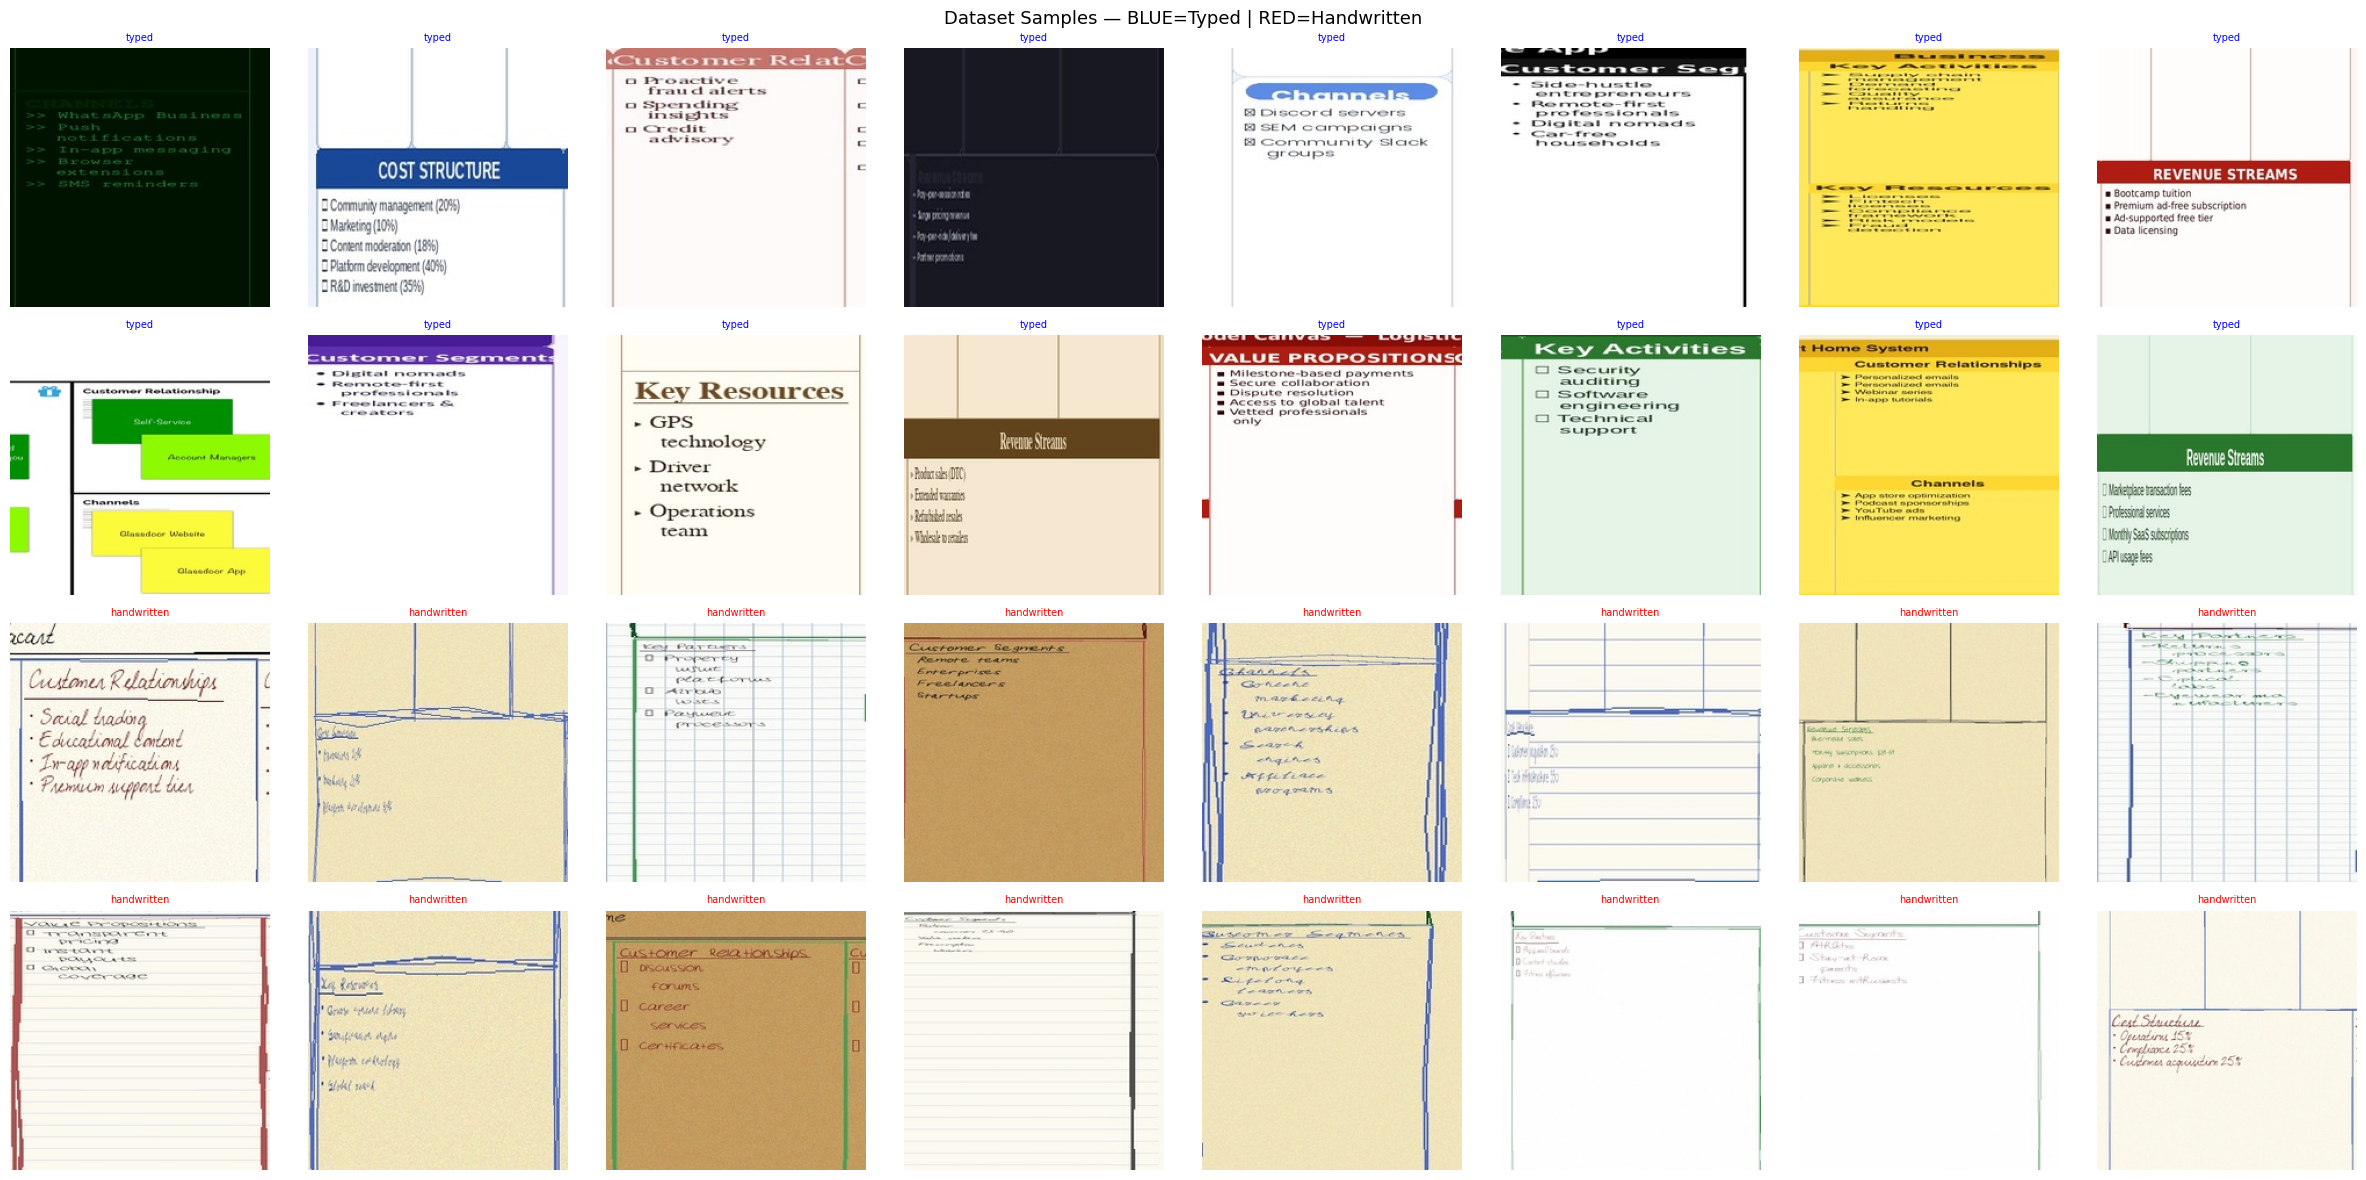

Class distribution:
  train : typed=3500 | handwritten=3500 | typed ratio=50.0%
  val   : typed=750 | handwritten=750 | typed ratio=50.0%
  test  : typed=750 | handwritten=750 | typed ratio=50.0%
/kaggle/working/cnn2_data/train/typed exists: True
  files: 3500
/kaggle/working/cnn2_data/train/handwritten exists: True
  files: 3500
/kaggle/working/cnn2_data/val/typed exists: True
  files: 750
/kaggle/working/cnn2_data/val/handwritten exists: True
  files: 750
/kaggle/working/cnn2_data/test/typed exists: True
  files: 750
/kaggle/working/cnn2_data/test/handwritten exists: True
  files: 750


In [17]:
# ============================================================
# CELL 3 — Visualize Dataset Samples  [UNCHANGED]
# ============================================================

fig, axes = plt.subplots(4, 8, figsize=(24, 12))

for row, cls in enumerate(['typed', 'handwritten']):
    imgs   = list((DATA_DIR / 'train' / cls).glob('*.jpg'))
    sample = random.sample(imgs, min(8, len(imgs)))
    for col, img_path in enumerate(sample):
        ax = axes[row * 2][col]
        ax.imshow(Image.open(img_path))
        ax.set_title(cls, fontsize=7,
                     color='blue' if cls == 'typed' else 'red')
        ax.axis('off')
        ax2 = axes[row * 2 + 1][col]
        alt_sample = random.sample(imgs, min(8, len(imgs)))
        if col < len(alt_sample):
            ax2.imshow(Image.open(alt_sample[col]))
            ax2.set_title(cls, fontsize=7,
                          color='blue' if cls == 'typed' else 'red')
        ax2.axis('off')

plt.suptitle(
    "Dataset Samples — BLUE=Typed | RED=Handwritten",
    fontsize=13
)
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'dataset_samples.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Class distribution:")
for split in ['train', 'val', 'test']:
    n_t   = len(list((DATA_DIR/split/'typed').glob('*.jpg')))
    n_h   = len(list((DATA_DIR/split/'handwritten').glob('*.jpg')))
    ratio = n_t / (n_t + n_h) if (n_t + n_h) > 0 else 0
    print(f"  {split:<6}: typed={n_t} | handwritten={n_h} | typed ratio={ratio:.1%}")

for split in ["train", "val", "test"]:
    for cls in ["typed", "handwritten"]:
        p = DATA_DIR / split / cls
        print(p, "exists:", p.exists())
        if p.exists():
            print("  files:", len(list(p.glob("*"))))

Image size    : 224×224
N_PATCHES     : 16 horizontal strips
Each strip    : 224×14 px
Flattened dim : 9408 per strip
Train:7000 | Val:1500 | Test:1500
Typed:3500 | Handwritten:3500


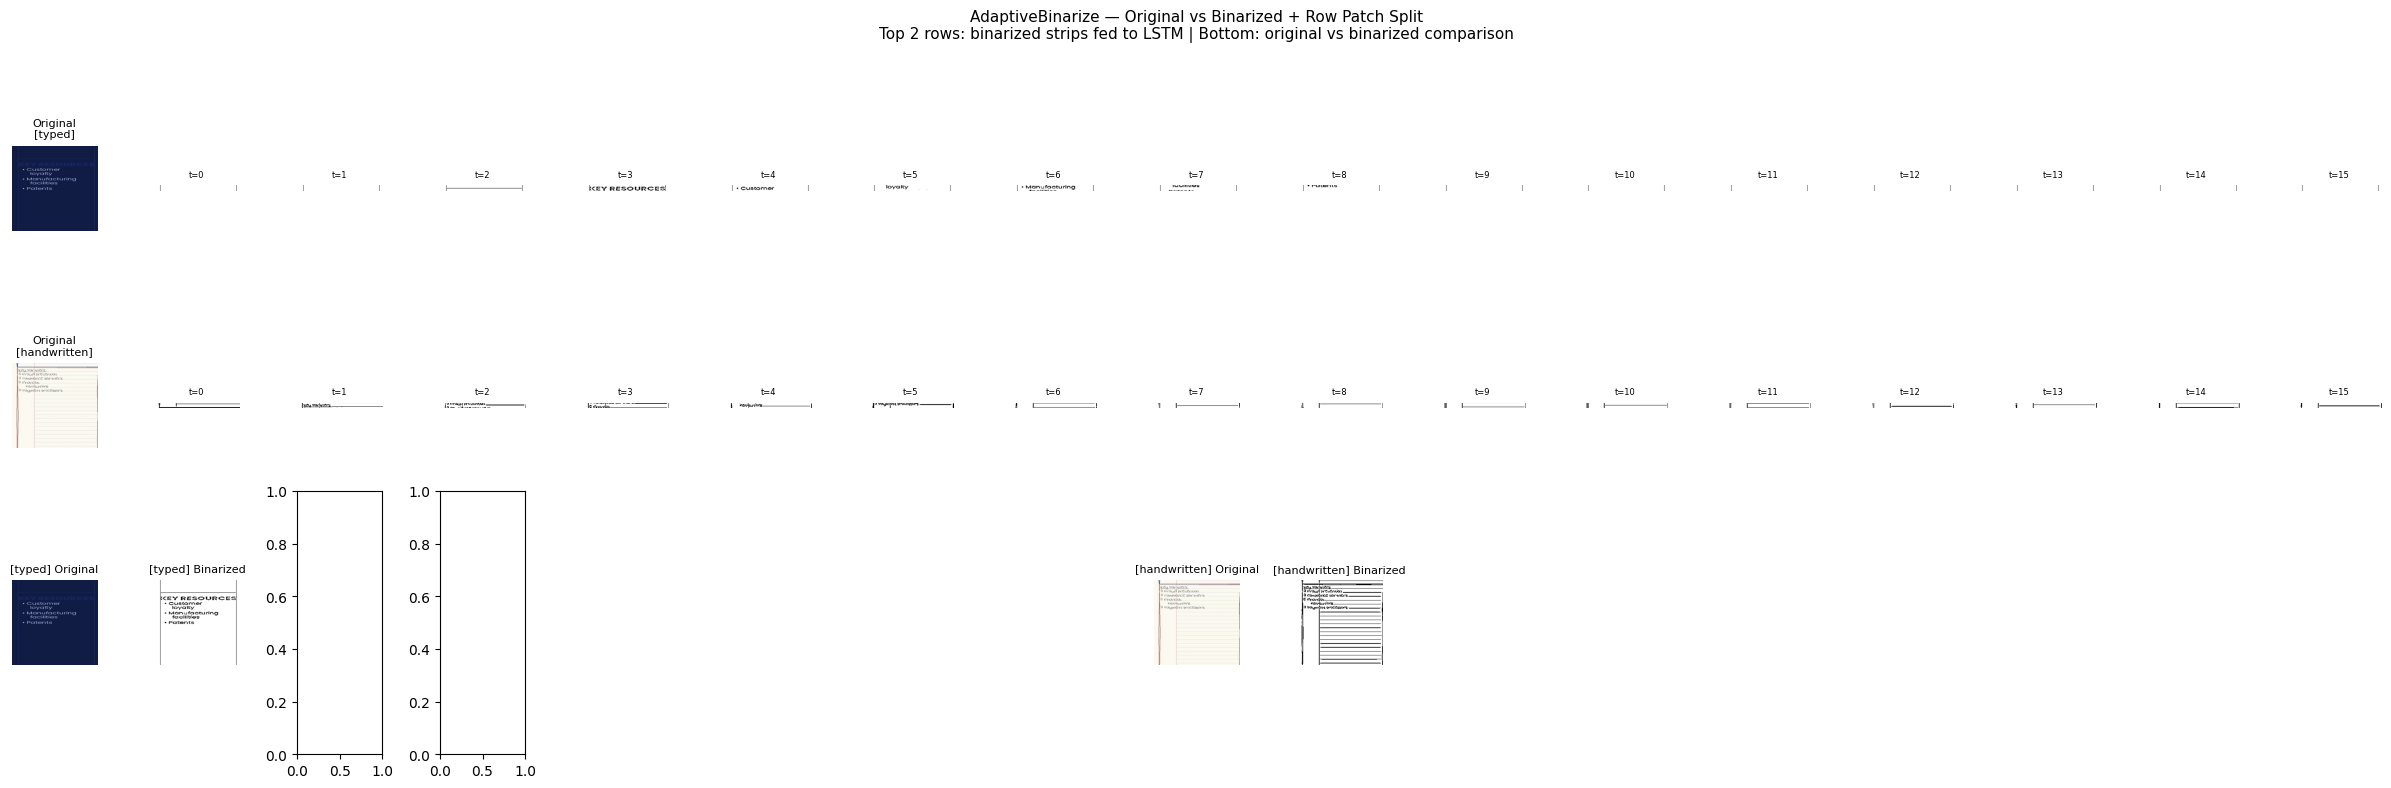

Cell 4 ready ✅


In [18]:
# ============================================================
# CELL 4 — Transforms + Row-Patch Dataset  [UPDATED v2]
# ============================================================
#
# IMAGE PREPROCESSING CHANGE:
#   Previous: NormalizeAppearance → grayscale + autocontrast only
#   New:      AdaptiveThreshold preprocessing baked into the transform
#
# WHY ADAPTIVE THRESHOLD INSTEAD OF PURE BLACK/WHITE:
#   Pure global binarization (e.g. Otsu) uses one threshold for the
#   whole image. BMC crop photos often have uneven lighting — a shadow
#   on one side means the same gray value means "text" on the right
#   and "background" on the left.
#   Adaptive threshold computes a local threshold per small region
#   (blockSize=15) so it handles uneven lighting correctly.
#   Result: clean black strokes on white background everywhere,
#   even when the original photo has gradients or shadows.
#
# WHY THIS HELPS THE LSTM:
#   The LSTM reads row strips. If a strip has mixed background colors
#   (gray, beige, blue), the model may focus on color instead of
#   stroke pattern. After adaptive thresholding every strip is purely
#   black-on-white — the only signal left is stroke geometry.
#
# AUGMENTATIONS UNCHANGED:
#   RandomHorizontalFlip, RandomRotation(5), ColorJitter removed
#   (no point jittering a binarized image — it's already B&W)
#   RandomMorphology kept — varies stroke thickness after binarization
#   RandomErasing kept — simulates missing text regions

import cv2
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageOps
from pathlib import Path

IMG_SIZE   = 224
N_PATCHES  = 16
PATCH_H    = IMG_SIZE // N_PATCHES       # 14px per strip
PATCH_DIM  = IMG_SIZE * PATCH_H * 3     # 9408 per strip (flattened RGB)
BATCH_SIZE = 32

print(f"Image size    : {IMG_SIZE}×{IMG_SIZE}")
print(f"N_PATCHES     : {N_PATCHES} horizontal strips")
print(f"Each strip    : {IMG_SIZE}×{PATCH_H} px")
print(f"Flattened dim : {PATCH_DIM} per strip")


class AdaptiveBinarize:
    """
    Convert image to clean black strokes on white background.

    Steps:
      1. Convert to grayscale
      2. Invert if background is dark (text should be dark on white)
      3. Apply adaptive Gaussian threshold per local block
         blockSize=15: neighborhood size for local threshold
         C=4: constant subtracted from local mean
      4. Convert back to RGB (LSTM expects 3 channels,
         but all 3 channels will be identical — pure B&W)

    Result: every pixel is either 0 (stroke) or 255 (background).
    No shades of gray — only structure remains.

    Better than global Otsu for BMC crops because:
      - Handles uneven lighting from photo angle
      - Handles colored section backgrounds (blue, yellow)
      - Handles shadow gradients across the canvas
    """
    def __call__(self, img: Image.Image) -> Image.Image:
        # Step 1: to grayscale numpy
        gray = np.array(img.convert('L'))

        # Step 2: invert if background is dark
        if gray.mean() < 127:
            gray = cv2.bitwise_not(gray)

        # Step 3: adaptive threshold
        binary = cv2.adaptiveThreshold(
            gray,
            maxValue=255,
            adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            thresholdType=cv2.THRESH_BINARY,
            blockSize=15,   # local neighborhood — adjust if text is small
            C=4             # subtracted from local mean — higher = more aggressive
        )

        # Step 4: back to 3-channel PIL
        return Image.fromarray(binary).convert('RGB')


class RandomMorphology:
    """Random erode/dilate on binarized image — varies stroke thickness."""
    def __init__(self, probability=0.4, max_kernel=3):
        self.probability = probability
        self.max_kernel  = max_kernel

    def __call__(self, img: Image.Image) -> Image.Image:
        if random.random() > self.probability:
            return img
        arr    = np.array(img.convert('L'))
        k      = random.choice(range(2, self.max_kernel + 1))
        kernel = np.ones((k, k), np.uint8)
        # Image is already binarized — text is black (0), bg is white (255)
        # Erode expands black → thicker strokes
        # Dilate shrinks black → thinner strokes
        proc = cv2.erode(arr, kernel) if random.random() < 0.5 \
               else cv2.dilate(arr, kernel)
        return Image.fromarray(proc).convert('RGB')


# ── Training transform ────────────────────────────────────────
# ColorJitter removed — no point on a binarized image
# Rotation kept small (5°) — preserves row ordering for LSTM
train_transforms = transforms.Compose([
    AdaptiveBinarize(),                                    # ← NEW: clean B&W
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: RandomMorphology(0.4)(img)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    # Normalize: mean=0.5, std=0.5 maps [0,1] → [-1,1]
    # For a B&W image: black(0) → -1, white(255) → +1
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08)),
])

# ── Val/test transform ────────────────────────────────────────
val_transforms = transforms.Compose([
    AdaptiveBinarize(),                                    # ← NEW: same pipeline
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


def image_to_row_patches(tensor: torch.Tensor) -> torch.Tensor:
    """
    [C, H, W] → [N_PATCHES, PATCH_DIM]
    Splits image into N_PATCHES horizontal strips, flattens each.
    """
    C, H, W = tensor.shape
    patches  = tensor.reshape(C, N_PATCHES, PATCH_H, W)
    patches  = patches.permute(1, 0, 2, 3)
    patches  = patches.reshape(N_PATCHES, -1)
    return patches


class BMCTextDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir     = Path(root_dir)
        self.transform    = transform
        self.class_to_idx = {'typed': 0, 'handwritten': 1}
        self.samples      = []
        for cls_name, label in self.class_to_idx.items():
            cls_dir = self.root_dir / cls_name
            if not cls_dir.exists():
                continue
            for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']:
                for p in cls_dir.glob(ext):
                    self.samples.append((p, label))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=200)
        if self.transform:
            img = self.transform(img)
        patches = image_to_row_patches(img)
        return patches, label

    def get_class_counts(self):
        counts = {0: 0, 1: 0}
        for _, label in self.samples:
            counts[label] += 1
        return counts


def mixup_collate(batch, alpha=0.2):
    patches, labels = zip(*batch)
    patches = torch.stack(patches)
    labels  = torch.tensor(labels, dtype=torch.long)
    if alpha > 0 and random.random() < 0.5:
        lam     = np.random.beta(alpha, alpha)
        idx     = torch.randperm(patches.size(0))
        patches = lam * patches + (1 - lam) * patches[idx]
        return patches, labels, labels[idx], lam
    return patches, labels, labels, 1.0


DATA_DIR = Path("/kaggle/working/cnn2_data")

train_dataset = BMCTextDataset(DATA_DIR / 'train', transform=train_transforms)
val_dataset   = BMCTextDataset(DATA_DIR / 'val',   transform=val_transforms)
test_dataset  = BMCTextDataset(DATA_DIR / 'test',  transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2,
                          pin_memory=True, collate_fn=mixup_collate)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

counts = train_dataset.get_class_counts()
print(f"Train:{len(train_dataset)} | Val:{len(val_dataset)} | Test:{len(test_dataset)}")
print(f"Typed:{counts[0]} | Handwritten:{counts[1]}")

# ── Visual demo: compare original vs binarized + row patches ──
fig, axes = plt.subplots(3, N_PATCHES + 1, figsize=(24, 8))

for row_idx, (cls_label, cls_name) in enumerate([(0, 'typed'), (1, 'handwritten')]):
    samples = [s for s in train_dataset.samples if s[1] == cls_label]
    if not samples:
        continue
    img_path = samples[0][0]
    orig     = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    binarized = AdaptiveBinarize()(orig)
    arr       = np.array(binarized)

    axes[row_idx][0].imshow(orig)
    axes[row_idx][0].set_title(f'Original\n[{cls_name}]', fontsize=8)
    axes[row_idx][0].axis('off')

    for i in range(N_PATCHES):
        strip = arr[i * PATCH_H:(i + 1) * PATCH_H, :, :]
        axes[row_idx][i + 1].imshow(strip, cmap='gray')
        axes[row_idx][i + 1].set_title(f't={i}', fontsize=6)
        axes[row_idx][i + 1].axis('off')

# Row 2: show side-by-side original vs binarized for both classes
for col_idx, (cls_label, cls_name) in enumerate([(0, 'typed'), (1, 'handwritten')]):
    samples = [s for s in train_dataset.samples if s[1] == cls_label]
    if not samples:
        continue
    orig      = Image.open(samples[0][0]).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    binarized = AdaptiveBinarize()(orig)
    ax_orig   = axes[2][col_idx * (N_PATCHES // 2)]
    ax_bin    = axes[2][col_idx * (N_PATCHES // 2) + 1]
    ax_orig.imshow(orig)
    ax_orig.set_title(f'[{cls_name}] Original', fontsize=8)
    ax_orig.axis('off')
    ax_bin.imshow(binarized, cmap='gray')
    ax_bin.set_title(f'[{cls_name}] Binarized', fontsize=8)
    ax_bin.axis('off')

for ax in axes[2][4:]:
    ax.axis('off')

plt.suptitle(
    'AdaptiveBinarize — Original vs Binarized + Row Patch Split\n'
    'Top 2 rows: binarized strips fed to LSTM | Bottom: original vs binarized comparison',
    fontsize=11
)
plt.tight_layout()
plt.savefig('/kaggle/working/binarize_patches_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cell 4 ready ✅')

In [19]:
# ============================================================
# CELL 5 — LSTM Architecture from Scratch  [UPDATED]
# ============================================================
#
# ARCHITECTURE:
#   Input [B, N_PATCHES, PATCH_DIM]
#     → PatchEmbedding: Linear(9408→256) + LayerNorm + ReLU + Dropout
#     → LSTM(256, hidden=256, layers=2, dropout=0.3)
#     → AttentionPooling  → context [B,256] + weights [B,N_PATCHES]
#     → Classifier: Dropout→Linear→LayerNorm→ReLU→Dropout→Linear
#     → logits [B, 2]
#
# forward() returns (logits, attn_weights) — weights used in XAI.

import torch
import torch.nn as nn
import torch.nn.functional as F

EMBED_DIM   = 256
HIDDEN_SIZE = 256
NUM_LAYERS  = 2
NUM_CLASSES = 2


class PatchEmbedding(nn.Module):
    """
    Projects each flattened row strip (9408-dim) to a
    lower-dimensional embedding (256-dim).
    Without this, the LSTM input would be too large to train.
    """
    def __init__(self, patch_dim: int, embed_dim: int, dropout: float = 0.2):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(patch_dim, embed_dim, bias=False),
            nn.LayerNorm(embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.proj(x)   # [B, N_PATCHES, EMBED_DIM]


class AttentionPooling(nn.Module):
    """
    Additive (Bahdanau-style) attention over LSTM timesteps.
    score(t) = v^T * tanh(W * h_t)
    alpha    = softmax(scores)
    context  = sum_t(alpha_t * h_t)
    Returns context vector and attention weights (saved for XAI).
    """
    def __init__(self, hidden_size: int):
        super().__init__()
        self.W = nn.Linear(hidden_size, hidden_size, bias=True)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_out: torch.Tensor):
        # lstm_out: [B, N_PATCHES, HIDDEN_SIZE]
        scores  = self.v(torch.tanh(self.W(lstm_out)))  # [B, N_PATCHES, 1]
        weights = F.softmax(scores.squeeze(-1), dim=1)  # [B, N_PATCHES]
        context = (weights.unsqueeze(-1) * lstm_out).sum(dim=1)  # [B, HIDDEN]
        return context, weights


class BMCTextLSTM(nn.Module):
    """
    Full LSTM classifier — all weights from scratch.
    forward() returns (logits, attn_weights) always.
    """
    def __init__(self,
                 patch_dim:   int = PATCH_DIM,
                 embed_dim:   int = EMBED_DIM,
                 hidden_size: int = HIDDEN_SIZE,
                 num_layers:  int = NUM_LAYERS,
                 num_classes: int = NUM_CLASSES,
                 dropout:     float = 0.3):
        super().__init__()

        self.patch_embed = PatchEmbedding(patch_dim, embed_dim, dropout=0.2)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False,
        )

        self.attention = AttentionPooling(hidden_size)

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size, 128),
            nn.LayerNorm(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
                # Set forget gate bias to 1 — helps gradient flow early
                n = param.size(0)
                param.data[n//4:n//2].fill_(1.0)
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, patches: torch.Tensor):
        # patches: [B, N_PATCHES, PATCH_DIM]
        embedded    = self.patch_embed(patches)       # [B, T, EMBED_DIM]
        lstm_out, _ = self.lstm(embedded)             # [B, T, HIDDEN_SIZE]
        context, weights = self.attention(lstm_out)   # [B,H], [B,T]
        logits      = self.classifier(context)        # [B, num_classes]
        return logits, weights


model = BMCTextLSTM(
    patch_dim=PATCH_DIM,
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=0.3,
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total:,}')
print(f'Trainable parameters : {trainable:,}')

# Smoke test
dummy        = torch.zeros(2, N_PATCHES, PATCH_DIM).to(device)
logits, attn = model(dummy)
print(f'Logits shape         : {logits.shape}')          # [2, 2]
print(f'Attention shape      : {attn.shape}')            # [2, 16]
print(f'Attention sum (≈1)   : {attn[0].sum().item():.4f}')
print('Model ready ✅')

Total parameters     : 3,561,090
Trainable parameters : 3,561,090
Logits shape         : torch.Size([2, 2])
Attention shape      : torch.Size([2, 16])
Attention sum (≈1)   : 1.0000
Model ready ✅


In [20]:
# ============================================================
# CELL — Class Balance Check  [UNCHANGED]
# ============================================================

from pathlib import Path
from collections import Counter

DATA_DIR = Path("/kaggle/working/cnn2_data")

for split in ['train', 'val', 'test']:
    n_typed = len(list((DATA_DIR/split/'typed').glob('*.jpg')))
    n_hw    = len(list((DATA_DIR/split/'handwritten').glob('*.jpg')))
    ratio   = n_typed / max(n_typed + n_hw, 1)
    print(f"{split}: typed={n_typed} | handwritten={n_hw} | "
          f"typed_ratio={ratio:.1%}")
    if ratio > 0.60:
        print(f"  ⚠️  Typed class dominates")
    elif ratio < 0.40:
        print(f"  ⚠️  Handwritten class dominates")
    else:
        print(f"  ✅ Balanced")

train: typed=3500 | handwritten=3500 | typed_ratio=50.0%
  ✅ Balanced
val: typed=750 | handwritten=750 | typed_ratio=50.0%
  ✅ Balanced
test: typed=750 | handwritten=750 | typed_ratio=50.0%
  ✅ Balanced


In [21]:
# ============================================================
# CELL 6 — Training Setup  [UPDATED]
# ============================================================
#
# Changes from CNN version:
#   LR lowered to 2e-4 (LSTMs more sensitive to high LR)
#   Scheduler patience raised to 5 (LSTMs converge slower)
#   Save path renamed to bmc_text_lstm_best.pt
#   Gradient clipping enforced in Cell 7 (max_norm=1.0)

import torch.optim as optim

WORK_DIR     = Path('/kaggle/working')
SAVE_PATH    = WORK_DIR / 'bmc_text_lstm_best.pt'
EPOCHS       = 50
LR           = 2e-4
WEIGHT_DECAY = 1e-3
MIN_EPOCH    = 10
PATIENCE     = 12

DATA_DIR = Path('/kaggle/working/cnn2_data')
n_typed  = len(list((DATA_DIR / 'train' / 'typed').glob('*.jpg')))
n_hw     = len(list((DATA_DIR / 'train' / 'handwritten').glob('*.jpg')))
n_total  = n_typed + n_hw
w_typed  = n_total / (2 * n_typed) if n_typed > 0 else 1.0
w_hw     = n_total / (2 * n_hw)    if n_hw    > 0 else 1.0

print(f'Class counts  — typed: {n_typed} | handwritten: {n_hw}')
print(f'Class weights — typed: {w_typed:.3f} | hw: {w_hw:.3f}')

class_weights = torch.tensor([w_typed, w_hw], dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
)

print(f'\nEpochs       : {EPOCHS}')
print(f'Min save ep  : {MIN_EPOCH}')
print(f'LR           : {LR}')
print(f'Grad clip    : 1.0  (essential for LSTM)')
print(f'Loss         : CrossEntropyLoss (weighted + label_smoothing=0.1)')
print(f'Optimizer    : Adam')
print(f'Scheduler    : ReduceLROnPlateau (patience=5)')
print('Training setup ready ✅')

Class counts  — typed: 3500 | handwritten: 3500
Class weights — typed: 1.000 | hw: 1.000

Epochs       : 50
Min save ep  : 10
LR           : 0.0002
Grad clip    : 1.0  (essential for LSTM)
Loss         : CrossEntropyLoss (weighted + label_smoothing=0.1)
Optimizer    : Adam
Scheduler    : ReduceLROnPlateau (patience=5)
Training setup ready ✅


In [22]:
# ============================================================
# CELL 7 — Training Loop  [UPDATED]
# ============================================================
#
# Key changes from CNN version:
#   model(patches) returns (logits, attn_weights) — unpack both.
#   Gradient clipping BEFORE optimizer.step() — non-optional for LSTM.
#   Save path is bmc_text_lstm_best.pt.
#   Save dict includes LSTM config fields (n_patches, patch_dim, etc.).

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'lr':         []
}

best_val_loss  = float('inf')
best_val_acc   = 0.0
patience_count = 0

print(f'Training LSTM for up to {EPOCHS} epochs (patience={PATIENCE})')
print(f'Saving by VAL LOSS | min epoch {MIN_EPOCH} | grad clip 1.0\n')

for epoch in range(EPOCHS):

    # ── Train ──────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for batch in train_loader:
        if len(batch) == 4:
            patches, labels_a, labels_b, lam = batch
        else:
            patches, labels_a = batch
            labels_b, lam = labels_a, 1.0

        patches  = patches.to(device)    # [B, N_PATCHES, PATCH_DIM]
        labels_a = labels_a.to(device)
        labels_b = labels_b.to(device)

        logits, _ = model(patches)       # discard attn during training

        loss = (lam * criterion(logits, labels_a) +
                (1 - lam) * criterion(logits, labels_b))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # LSTM essential
        optimizer.step()

        train_loss    += loss.item() * patches.size(0)
        preds          = logits.argmax(dim=1)
        train_correct += (preds == labels_a).sum().item()
        train_total   += patches.size(0)

    # ── Validate ───────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for patches, labels in val_loader:
            patches = patches.to(device)
            labels  = labels.to(device)
            logits, _ = model(patches)
            loss       = criterion(logits, labels)
            val_loss    += loss.item() * patches.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += patches.size(0)

    e_train_loss = train_loss / train_total
    e_train_acc  = train_correct / train_total
    e_val_loss   = val_loss / val_total
    e_val_acc    = val_correct / val_total
    current_lr   = optimizer.param_groups[0]['lr']

    history['train_loss'].append(e_train_loss)
    history['train_acc'].append(e_train_acc)
    history['val_loss'].append(e_val_loss)
    history['val_acc'].append(e_val_acc)
    history['lr'].append(current_lr)

    prev_lr = current_lr
    scheduler.step(e_val_loss)
    new_lr  = optimizer.param_groups[0]['lr']
    lr_msg  = f' ⬇️ LR→{new_lr:.6f}' if new_lr < prev_lr else ''

    # ── Save logic (same criteria as CNN version) ───────────
    saved = ''
    if epoch >= MIN_EPOCH:
        gap     = e_train_acc - e_val_acc
        gap_ok  = gap < 0.10
        loss_ok = e_val_loss < best_val_loss
        acc_ok  = e_val_acc > 0.70

        if loss_ok and gap_ok and acc_ok:
            best_val_loss = e_val_loss
            best_val_acc  = e_val_acc
            torch.save({
                'epoch':            epoch,
                'model_state_dict': model.state_dict(),
                'val_loss':         best_val_loss,
                'val_acc':          best_val_acc,
                'train_val_gap':    gap,
                'n_patches':        N_PATCHES,
                'patch_dim':        PATCH_DIM,
                'embed_dim':        EMBED_DIM,
                'hidden_size':      HIDDEN_SIZE,
            }, SAVE_PATH)
            saved = f' ← SAVED (loss={e_val_loss:.4f}, gap={gap*100:.1f}%)'
            patience_count = 0
        elif loss_ok and not gap_ok:
            saved = f' ⚠️ NOT SAVED — gap too large ({gap*100:.1f}%)'
            patience_count += 1
        elif loss_ok and not acc_ok:
            saved = f' ⚠️ NOT SAVED — acc too low ({e_val_acc*100:.1f}%)'
            patience_count += 1
        else:
            patience_count += 1
    else:
        patience_count = 0

    epoch_note = ' [too early]' if epoch < MIN_EPOCH else ''
    print(f'Epoch [{epoch+1:02d}/{EPOCHS}] '
          f'Train loss={e_train_loss:.4f} acc={e_train_acc:.4f} | '
          f'Val loss={e_val_loss:.4f} acc={e_val_acc:.4f} | '
          f'LR={new_lr:.6f}{saved}{lr_msg}{epoch_note}')

    if epoch >= MIN_EPOCH and patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

print(f'\nTraining complete ✅')
print(f'Best val loss : {best_val_loss:.4f}')
print(f'Best val acc  : {best_val_acc:.4f} ({best_val_acc*100:.1f}%)')

Training LSTM for up to 50 epochs (patience=12)
Saving by VAL LOSS | min epoch 10 | grad clip 1.0

Epoch [01/50] Train loss=0.6339 acc=0.6306 | Val loss=0.7051 acc=0.6327 | LR=0.000200 [too early]
Epoch [02/50] Train loss=0.5519 acc=0.7110 | Val loss=0.4376 acc=0.8640 | LR=0.000200 [too early]
Epoch [03/50] Train loss=0.5207 acc=0.7311 | Val loss=0.3817 acc=0.8940 | LR=0.000200 [too early]
Epoch [04/50] Train loss=0.4914 acc=0.7249 | Val loss=0.4529 acc=0.8173 | LR=0.000200 [too early]
Epoch [05/50] Train loss=0.4699 acc=0.7627 | Val loss=0.3637 acc=0.8980 | LR=0.000200 [too early]
Epoch [06/50] Train loss=0.4783 acc=0.7404 | Val loss=0.3328 acc=0.9180 | LR=0.000200 [too early]
Epoch [07/50] Train loss=0.4540 acc=0.7767 | Val loss=0.3328 acc=0.9173 | LR=0.000200 [too early]
Epoch [08/50] Train loss=0.4622 acc=0.7626 | Val loss=0.3281 acc=0.9153 | LR=0.000200 [too early]
Epoch [09/50] Train loss=0.4438 acc=0.7713 | Val loss=0.4213 acc=0.8367 | LR=0.000200 [too early]
Epoch [10/50] Train

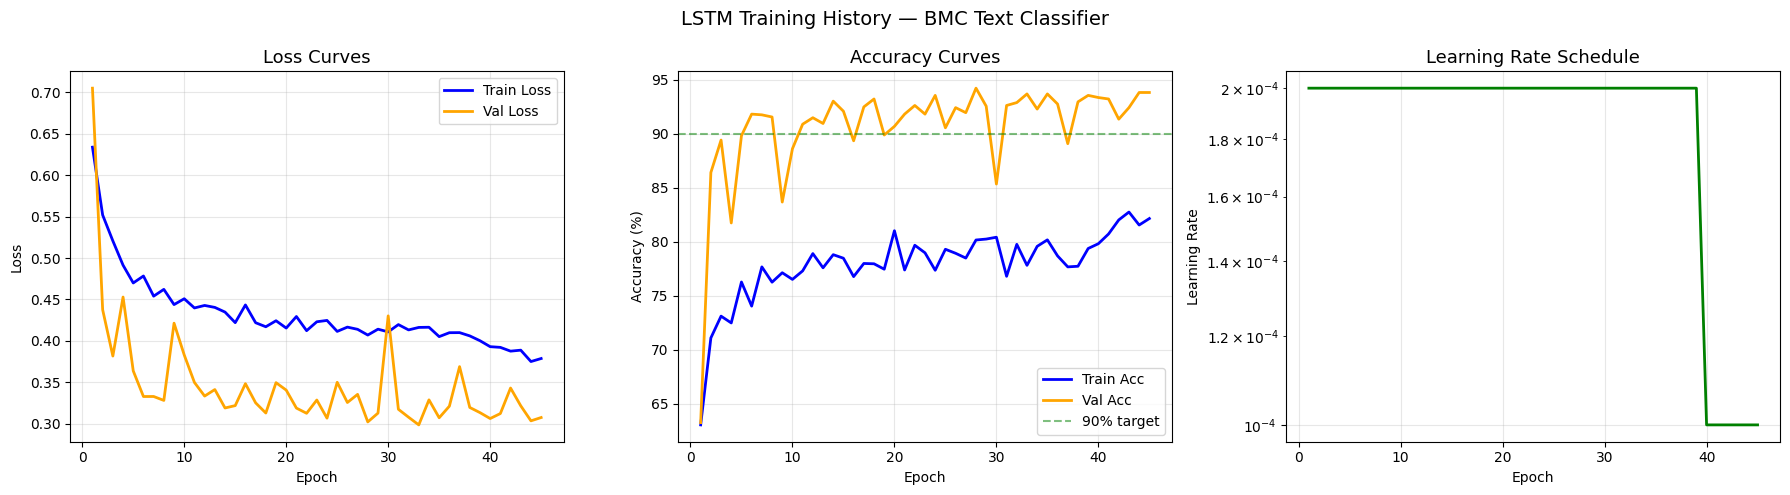

Final train accuracy : 0.8214 (82.1%)
Final val accuracy   : 0.9380   (93.8%)
Train-Val gap        : -0.1166 (-11.7%)
✅ Gap < 5% — model generalizes well


In [23]:
# ============================================================
# CELL 8 — Training Curves + Overfitting Check  [UNCHANGED]
# ============================================================

import matplotlib.pyplot as plt

epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(x, history['train_loss'], label='Train Loss', color='blue',  linewidth=2)
axes[0].plot(x, history['val_loss'],   label='Val Loss',   color='orange', linewidth=2)
axes[0].set_title('Loss Curves', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, [a*100 for a in history['train_acc']],
             label='Train Acc', color='blue',  linewidth=2)
axes[1].plot(x, [a*100 for a in history['val_acc']],
             label='Val Acc',   color='orange', linewidth=2)
axes[1].axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% target')
axes[1].set_title('Accuracy Curves', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, history['lr'], color='green', linewidth=2)
axes[2].set_title('Learning Rate Schedule', fontsize=13)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.suptitle('LSTM Training History — BMC Text Classifier', fontsize=14)
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

final_train_acc = history['train_acc'][-1]
final_val_acc   = history['val_acc'][-1]
gap             = final_train_acc - final_val_acc

print(f"Final train accuracy : {final_train_acc:.4f} ({final_train_acc*100:.1f}%)")
print(f"Final val accuracy   : {final_val_acc:.4f}   ({final_val_acc*100:.1f}%)")
print(f"Train-Val gap        : {gap:.4f} ({gap*100:.1f}%)")

if gap > 0.10:
    print("⚠️  Gap > 10% — model is overfitting")
elif gap > 0.05:
    print("⚠️  Gap 5-10% — slight overfitting")
else:
    print("✅ Gap < 5% — model generalizes well")

Loaded best model from epoch 33
Best val accuracy : 0.9367

=== TEST SET RESULTS ===
Accuracy  : 0.9460 (94.6%)
F1 Score  : 0.9459

Detailed Report:
              precision    recall  f1-score   support

       Typed       0.98      0.91      0.94       750
 Handwritten       0.92      0.98      0.95       750

    accuracy                           0.95      1500
   macro avg       0.95      0.95      0.95      1500
weighted avg       0.95      0.95      0.95      1500



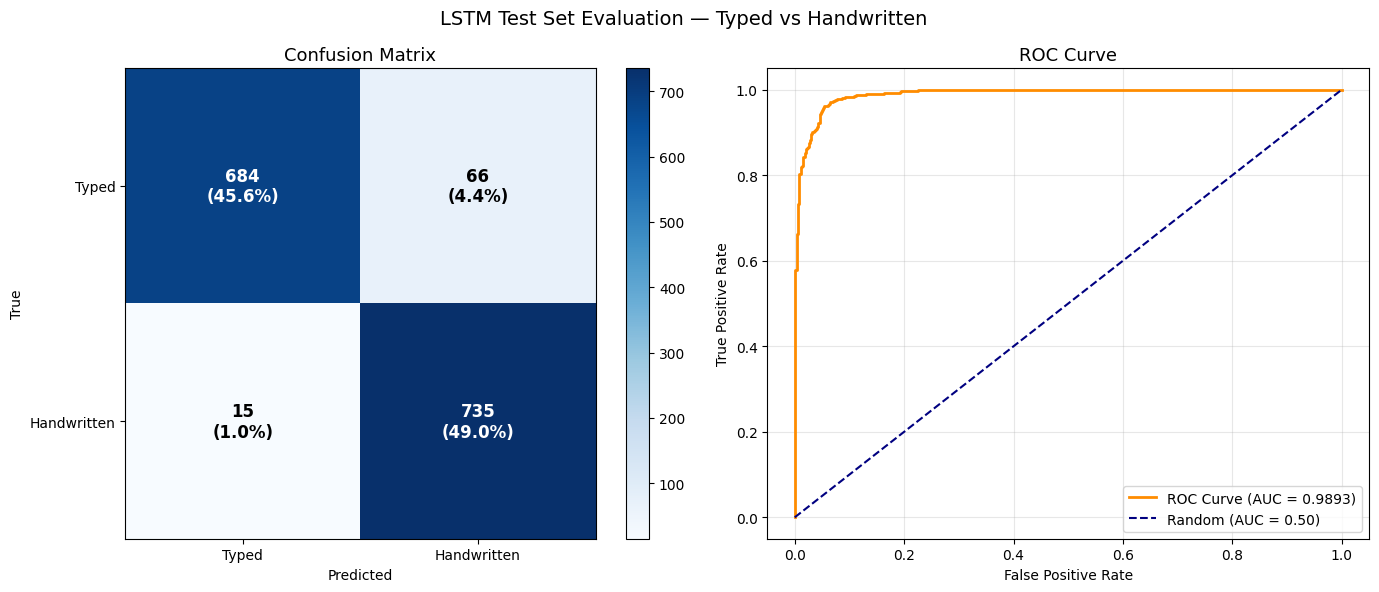


ROC AUC : 0.9893
✅ Excellent — AUC > 0.95


In [24]:
# ============================================================
# CELL 9 — Full Evaluation on Test Set  [UNCHANGED]
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, accuracy_score, f1_score)

checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best val accuracy : {checkpoint['val_acc']:.4f}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for patches, labels in test_loader:
        patches = patches.to(device)
        logits, _ = model(patches)
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average='weighted')
cm  = confusion_matrix(all_labels, all_preds)

print(f"\n=== TEST SET RESULTS ===")
print(f"Accuracy  : {acc:.4f} ({acc*100:.1f}%)")
print(f"F1 Score  : {f1:.4f}")
print(f"\nDetailed Report:")
print(classification_report(all_labels, all_preds,
      target_names=['Typed', 'Handwritten']))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Typed', 'Handwritten'])
axes[0].set_yticklabels(['Typed', 'Handwritten'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix', fontsize=13)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{cm[i,j]}\n({cm[i,j]/cm.sum()*100:.1f}%)",
                     ha='center', va='center', fontsize=12, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[0])

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', linewidth=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--',
             label='Random (AUC = 0.50)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM Test Set Evaluation — Typed vs Handwritten', fontsize=14)
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'test_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nROC AUC : {roc_auc:.4f}")
if roc_auc > 0.95:
    print("✅ Excellent — AUC > 0.95")
elif roc_auc > 0.90:
    print("✅ Good — AUC > 0.90")
elif roc_auc > 0.80:
    print("⚠️  Acceptable — AUC > 0.80")
else:
    print("❌ Poor — AUC < 0.80, model needs improvement")

Loaded LSTM checkpoint — epoch 33 | val_acc=0.9367
Typed crops available    : 10421
Handwritten crops avail. : 9585
Testing on 9 crops (5 typed + 4 handwritten)


/tmp/ipykernel_57/615431999.py:58: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/615431999.py:59: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(str(WORK_DIR / 'real_crop_test.png'), dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


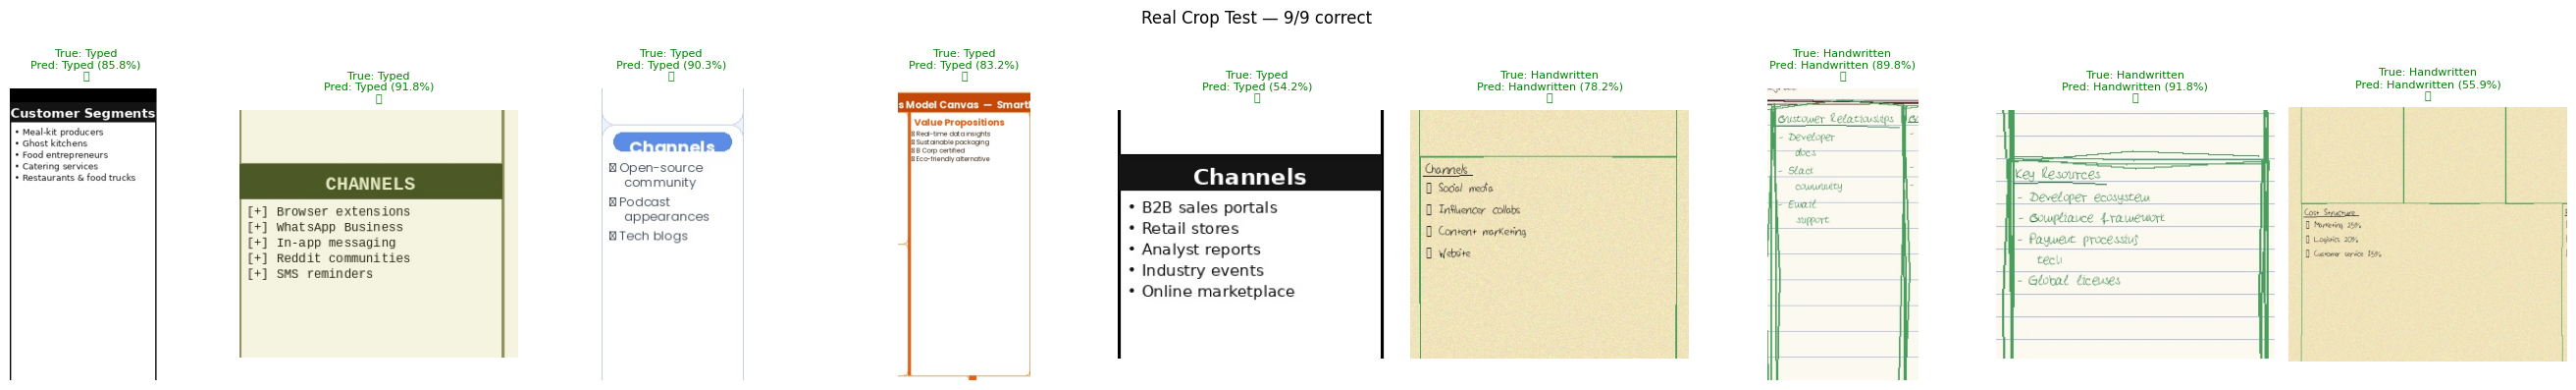

Real crop accuracy: 9/9 = 100.0%

Export complete ✅
Upload bmc_text_cnn_best.pt to Kaggle dataset → classification-model
Notebook 2 (LSTM) complete ✅


In [25]:
# ============================================================
# CELL 10 — Real Crop Test + Export  [UPDATED]
# ============================================================
#
# Same as CNN Cell 10 but model() returns (logits, attn_weights).
# Export filename kept as bmc_text_cnn_best.pt for NB3 compatibility.

import shutil, json

DATASET_PATH = Path('/kaggle/input/datasets/ghofranegharbi/typed-hanwritten-crops')
WORK_DIR     = Path('/kaggle/working')

checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded LSTM checkpoint — epoch {checkpoint["epoch"]+1} | '
      f'val_acc={checkpoint["val_acc"]:.4f}')

typed_crops  = list((DATASET_PATH / 'typed').rglob('*.jpg'))
hw_crops     = list((DATASET_PATH / 'handwritten').rglob('*.jpg'))
typed_sample = random.sample(typed_crops, min(5, len(typed_crops)))
hw_sample    = random.sample(hw_crops,    min(4, len(hw_crops)))
test_crops   = [(p, 0) for p in typed_sample] + [(p, 1) for p in hw_sample]

print(f"Typed crops available    : {len(typed_crops)}")
print(f"Handwritten crops avail. : {len(hw_crops)}")
print(f"Testing on {len(test_crops)} crops (5 typed + 4 handwritten)")

fig, axes = plt.subplots(1, len(test_crops), figsize=(3 * len(test_crops), 4))
class_names = ['Typed', 'Handwritten']
correct     = 0

for ax, (crop_path, true_label) in zip(axes, test_crops):
    img_pil = Image.open(crop_path).convert('RGB')
    tensor  = val_transforms(img_pil)                    # [C, H, W]
    patches = image_to_row_patches(tensor).unsqueeze(0).to(device)  # [1, N, D]

    with torch.no_grad():
        logits, attn = model(patches)
        probs = F.softmax(logits, dim=1)
        pred  = logits.argmax(1).item()
        conf  = probs[0][pred].item()

    is_correct = pred == true_label
    if is_correct:
        correct += 1

    ax.imshow(img_pil)
    ax.set_title(
        f'True: {class_names[true_label]}\n'
        f'Pred: {class_names[pred]} ({conf:.1%})\n'
        f'{"✅" if is_correct else "❌"}',
        color='green' if is_correct else 'red', fontsize=8
    )
    ax.axis('off')

plt.suptitle(f'Real Crop Test — {correct}/{len(test_crops)} correct', fontsize=12)
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'real_crop_test.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Real crop accuracy: {correct}/{len(test_crops)} = {correct/len(test_crops):.1%}')

# ── Export ─────────────────────────────────────────────────
export_dir = WORK_DIR / 'notebook2_output'
export_dir.mkdir(exist_ok=True)

# Keep filename bmc_text_cnn_best.pt so Notebook 3 path is unchanged
torch.save({
    'model_state_dict': model.state_dict(),
    'class_to_idx':     {'typed': 0, 'handwritten': 1},
    'img_size':         IMG_SIZE,
    'n_patches':        N_PATCHES,
    'patch_dim':        PATCH_DIM,
    'embed_dim':        EMBED_DIM,
    'hidden_size':      HIDDEN_SIZE,
    'architecture':     'BMCTextLSTM',
    'val_acc':          best_val_acc,
    'val_loss':         best_val_loss,
}, export_dir / 'bmc_text_cnn_best.pt')

config = {
    'architecture': 'BMCTextLSTM',
    'num_classes':  2,
    'class_names':  ['typed', 'handwritten'],
    'img_size':     IMG_SIZE,
    'n_patches':    N_PATCHES,
    'patch_dim':    PATCH_DIM,
    'embed_dim':    EMBED_DIM,
    'hidden_size':  HIDDEN_SIZE,
    'val_acc':      float(best_val_acc),
    'val_loss':     float(best_val_loss),
}
with open(export_dir / 'model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

shutil.make_archive(str(WORK_DIR / 'notebook2_output'), 'zip', str(export_dir))
print(f'\nExport complete ✅')
print(f'Upload bmc_text_cnn_best.pt to Kaggle dataset → classification-model')
print('Notebook 2 (LSTM) complete ✅')

Model loaded — val_acc=0.9367
=== XAI: Attention + GradCAM (on binarized input) ===


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


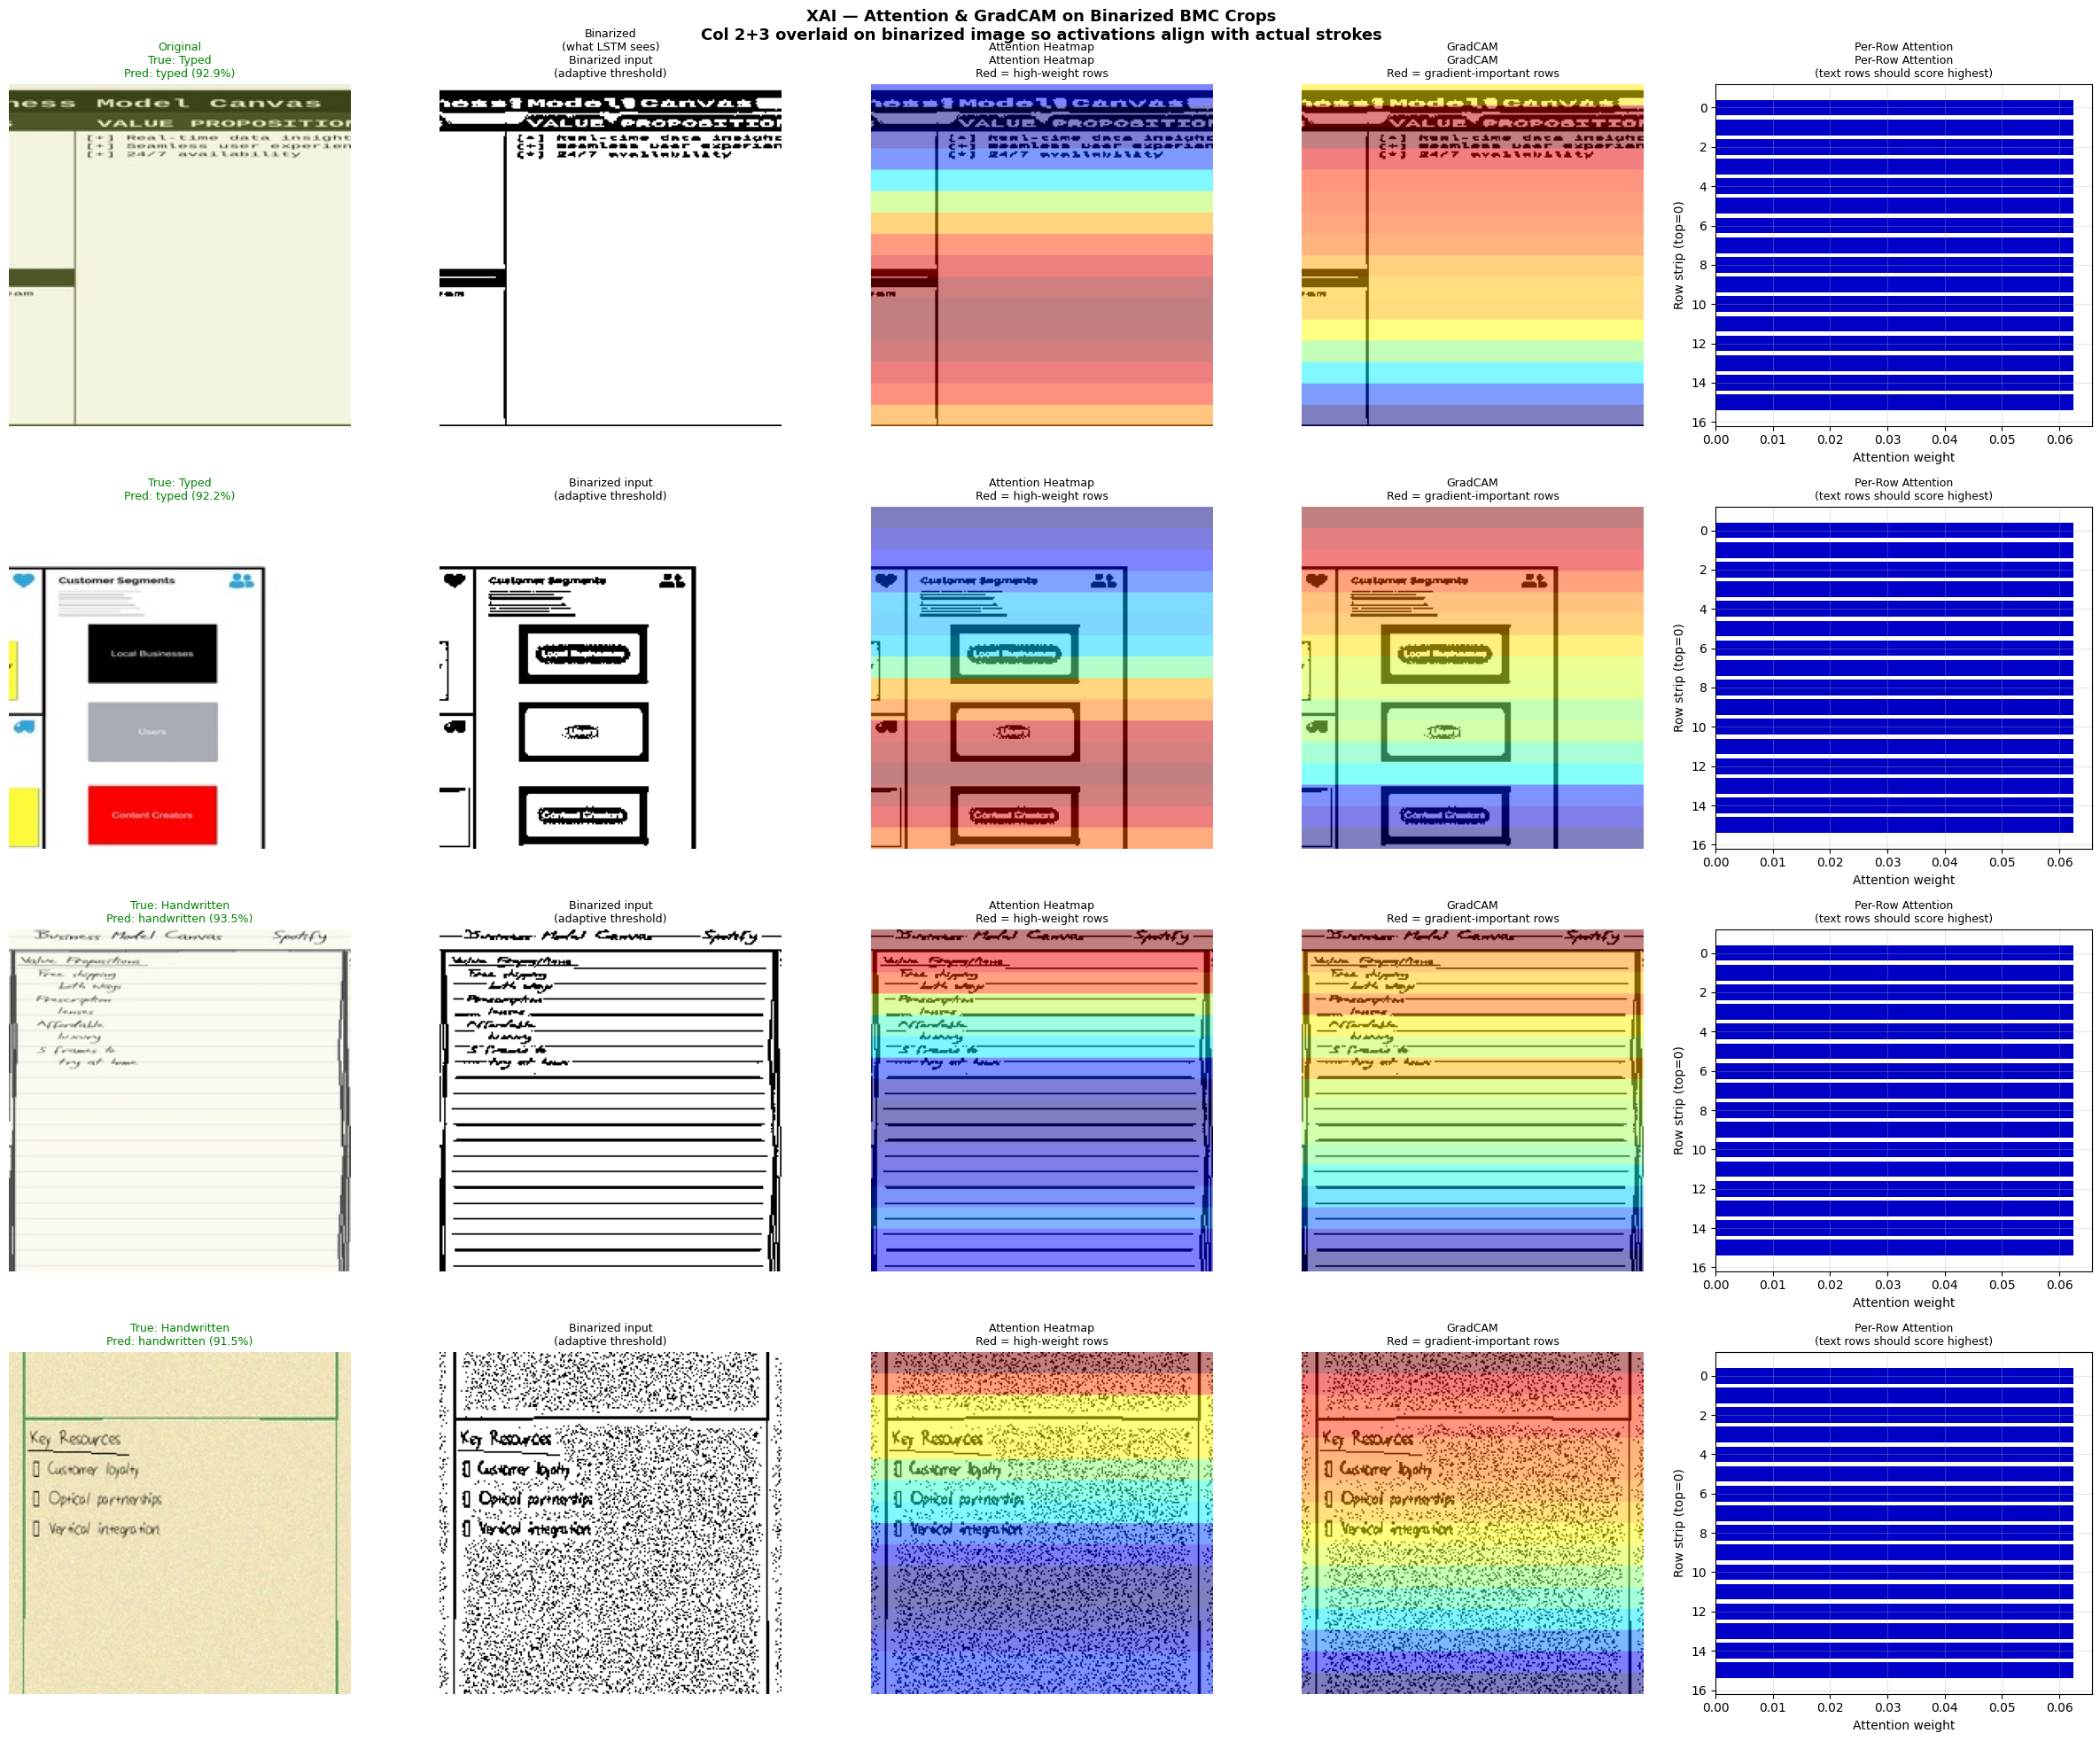

XAI visualization saved ✅

TEST 1 — Scrambled Pixel Test
After binarization, scrambling destroys row structure.
Good model → drops to ~50% confidence.
Scrambled typed → avg conf still typed : 36.82%
Scrambled hw    → avg conf still hw    : 61.43%
[OK] ✅  Spatial structure broken — confidence dropped correctly

TEST 2 — Blank Image
After binarization a blank white image stays white.
Expected: ~50% confidence (no strokes = no signal).
White → handwritten (60.23%) | top attention rows: [5, 4, 6]
  ✅  Reasonable uncertainty on blank image
Gray → handwritten (60.23%) | top attention rows: [5, 4, 6]
  ✅  Reasonable uncertainty on blank image
Black → handwritten (60.23%) | top attention rows: [5, 4, 6]
  ✅  Reasonable uncertainty on blank image

TEST 3 — Style Transfer on Binarized Images
Thickens strokes of typed crops to mimic handwriting weight.
Since images are already B&W, thickness IS the style signal.
Stroke-thickened typed images: 3/10 flipped to handwritten
[NOTE] ⚠️  Partial sensiti

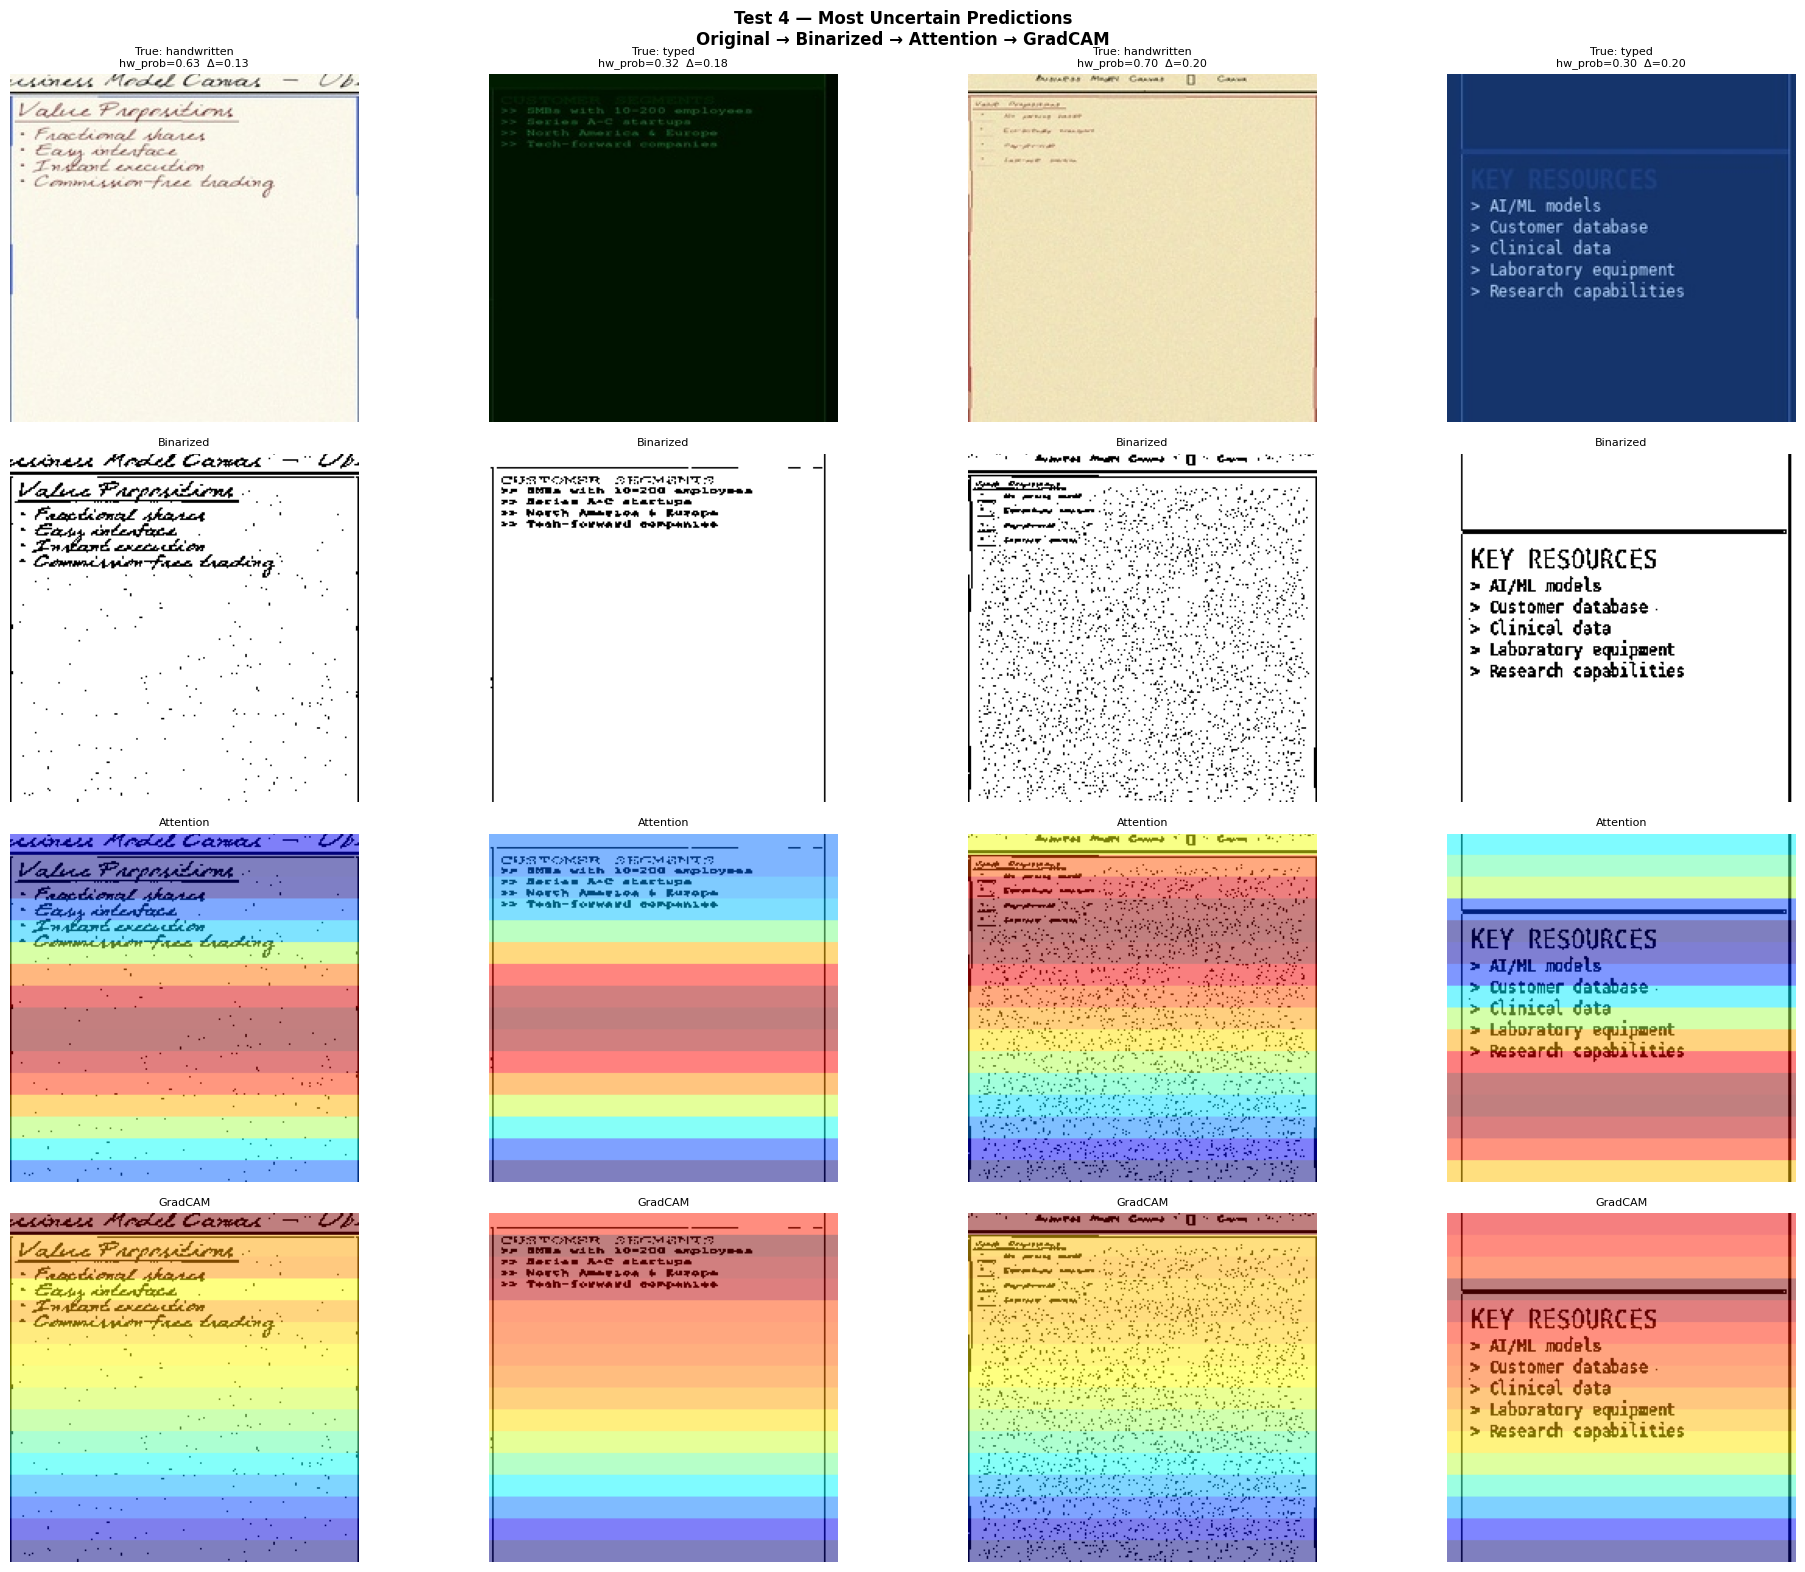


DIAGNOSTIC SUMMARY
Test 1 (scrambled)        : typed=36.8%  hw=61.4%
Test 2 (blank)            : see output above
Test 3 (stroke thickness) : 3/10 flipped
Test 4 (boundary)         : saved to diagnostic_boundary.png

XAI files saved:
  xai_attention_gradcam.png  — attention + GradCAM, binarized overlay
  diagnostic_boundary.png    — borderline cases, 4-row visualization
updating: kaggle/working/ (stored 0%)
updating: kaggle/working/dataset_samples.png (deflated 1%)
updating: kaggle/working/real_crop_test.png (deflated 2%)
updating: kaggle/working/row_patches_demo.png (deflated 15%)
updating: kaggle/working/cnn2_data/ (stored 0%)
updating: kaggle/working/cnn2_data/val/ (stored 0%)
updating: kaggle/working/cnn2_data/val/typed/ (stored 0%)
updating: kaggle/working/cnn2_data/val/typed/typed_val_00407.jpg (deflated 21%)
updating: kaggle/working/cnn2_data/val/typed/typed_val_00501.jpg (deflated 12%)
updating: kaggle/working/cnn2_data/val/typed/typed_val_00571.jpg (deflated 9%)
updating: kag

/kaggle/working/folder.zip

In [26]:
# ============================================================
# DIAGNOSTIC CELL — GradCAM + Attention + 4 Tests  [UPDATED]
# ============================================================
#
# XAI APPROACH:
#   METHOD 1 — Attention weights (built-in, per-row strip weights)
#   METHOD 2 — GradCAM via input-gradient on patch embeddings
#              Uses torch.backends.cudnn.flags(enabled=False)
#              to allow LSTM backward pass in eval mode without error
#
# The binarized images make GradCAM more interpretable:
#   RED rows = model focused on those text rows
#   Since background is always white, activation on a red row
#   genuinely means there was stroke content there

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import cv2
from PIL import Image, ImageFilter
from pathlib import Path

WORK_DIR  = Path('/kaggle/working')
DATA_DIR  = WORK_DIR / 'cnn2_data'

checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Model loaded — val_acc={checkpoint["val_acc"]:.4f}')

typed_imgs = list((DATA_DIR / 'test' / 'typed').glob('*.jpg'))[:20]
hw_imgs    = list((DATA_DIR / 'test' / 'handwritten').glob('*.jpg'))[:20]


def get_patches(img_pil):
    """PIL image → binarized → [1, N_PATCHES, PATCH_DIM] on device."""
    t = val_transforms(img_pil)
    p = image_to_row_patches(t)
    return p.unsqueeze(0).to(device)


def predict_lstm(img_pil):
    """Returns (class_name, confidence, attn_weights [N_PATCHES])."""
    patches = get_patches(img_pil)
    with torch.no_grad():
        logits, attn = model(patches)
        probs = F.softmax(logits, dim=1)
        pred  = logits.argmax(1).item()
        conf  = probs[0][pred].item()
    return ('typed' if pred == 0 else 'handwritten'), conf, attn[0].cpu().numpy()


def attention_heatmap(img_pil, attn_weights):
    """
    Overlay attention weights as a row heatmap on the BINARIZED image.
    Showing on the binarized version makes it clearer which text rows
    the model is focusing on vs which rows are empty whitespace.
    """
    # Apply binarization first so heatmap is on what the model actually sees
    binarized = AdaptiveBinarize()(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    img_arr   = np.array(binarized.convert('RGB'))

    heat_1d   = np.repeat(attn_weights, PATCH_H)
    heat_2d   = np.tile(heat_1d[:, np.newaxis], (1, IMG_SIZE))
    heat_norm = ((heat_2d - heat_2d.min()) /
                 (heat_2d.max() - heat_2d.min() + 1e-8) * 255).astype(np.uint8)
    heatmap   = cv2.applyColorMap(heat_norm, cv2.COLORMAP_JET)
    heatmap   = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay   = (0.5 * heatmap + 0.5 * img_arr).astype(np.uint8)
    return Image.fromarray(overlay)


def lstm_gradcam(img_pil, target_class):
    """
    Input-gradient GradCAM for LSTM on binarized input.

    Hooks PatchEmbedding output → backprops target class score →
    L2 norm of gradient per row strip → per-row importance.

    cudnn disabled during backward: required for LSTM eval-mode backward.
    """
    patches    = get_patches(img_pil)
    embed_grad = {}

    def bwd_hook(module, grad_in, grad_out):
        embed_grad['val'] = grad_out[0]

    h = model.patch_embed.proj.register_full_backward_hook(bwd_hook)

    with torch.backends.cudnn.flags(enabled=False):
        logits, _ = model(patches)
        model.zero_grad()
        logits[0, target_class].backward()

    h.remove()

    grads      = embed_grad['val'][0].detach().cpu()   # [N_PATCHES, EMBED_DIM]
    importance = grads.norm(dim=1).numpy()              # [N_PATCHES]
    importance = (importance - importance.min()) / \
                 (importance.max() - importance.min() + 1e-8)

    # Overlay on binarized image
    binarized = AdaptiveBinarize()(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    img_arr   = np.array(binarized.convert('RGB'))
    heat_1d   = np.repeat(importance, PATCH_H)
    heat_2d   = np.tile(heat_1d[:, np.newaxis], (1, IMG_SIZE))
    heat_norm = (heat_2d * 255).astype(np.uint8)
    heatmap   = cv2.applyColorMap(heat_norm, cv2.COLORMAP_JET)
    heatmap   = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay   = (0.5 * heatmap + 0.5 * img_arr).astype(np.uint8)

    return importance, Image.fromarray(overlay)


# ══════════════════════════════════════════════════════════
# XAI: Attention + GradCAM on binarized images
# ══════════════════════════════════════════════════════════
print('=== XAI: Attention + GradCAM (on binarized input) ===')

xai_samples = [
    (typed_imgs[0], 0, 'Typed'),
    (typed_imgs[1], 0, 'Typed'),
    (hw_imgs[0],   1, 'Handwritten'),
    (hw_imgs[1],   1, 'Handwritten'),
]

fig, axes = plt.subplots(len(xai_samples), 5,
                         figsize=(24, 5 * len(xai_samples)))

col_titles = ['Original', 'Binarized\n(what LSTM sees)',
              'Attention Heatmap', 'GradCAM', 'Per-Row Attention']

for row, (img_path, true_cls, label_name) in enumerate(xai_samples):
    img_pil   = Image.open(img_path).convert('RGB')
    binarized = AdaptiveBinarize()(img_pil.resize((IMG_SIZE, IMG_SIZE)))

    pred_label, conf, attn = predict_lstm(img_pil)
    gc_imp, gc_overlay     = lstm_gradcam(img_pil, true_cls)
    attn_overlay           = attention_heatmap(img_pil, attn)
    correct                = pred_label == label_name.lower()

    # Col 0: original
    axes[row][0].imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    axes[row][0].set_title(
        f'True: {label_name}\nPred: {pred_label} ({conf:.1%})',
        fontsize=9, color='green' if correct else 'red'
    )
    axes[row][0].axis('off')

    # Col 1: binarized (what the model actually sees)
    axes[row][1].imshow(binarized, cmap='gray')
    axes[row][1].set_title('Binarized input\n(adaptive threshold)', fontsize=9)
    axes[row][1].axis('off')

    # Col 2: attention heatmap on binarized
    axes[row][2].imshow(attn_overlay)
    axes[row][2].set_title('Attention Heatmap\nRed = high-weight rows', fontsize=9)
    axes[row][2].axis('off')

    # Col 3: GradCAM on binarized
    axes[row][3].imshow(gc_overlay)
    axes[row][3].set_title('GradCAM\nRed = gradient-important rows', fontsize=9)
    axes[row][3].axis('off')

    # Col 4: bar chart — attention weight per row
    colors = plt.cm.jet(attn[::-1])
    axes[row][4].barh(range(N_PATCHES), attn[::-1], color=colors)
    axes[row][4].set_xlabel('Attention weight')
    axes[row][4].set_ylabel('Row strip (top=0)')
    axes[row][4].set_title('Per-Row Attention\n(text rows should score highest)',
                            fontsize=9)
    axes[row][4].invert_yaxis()
    axes[row][4].grid(True, alpha=0.3)

    if row == 0:
        for col_idx, title in enumerate(col_titles):
            axes[0][col_idx].set_title(
                title + '\n' + axes[0][col_idx].get_title(), fontsize=9,
                color='green' if correct and col_idx == 0 else
                      'red'   if not correct and col_idx == 0 else 'black'
            )

plt.suptitle(
    'XAI — Attention & GradCAM on Binarized BMC Crops\n'
    'Col 2+3 overlaid on binarized image so activations align with actual strokes',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'xai_attention_gradcam.png'), dpi=150, bbox_inches='tight')
plt.show()
print('XAI visualization saved ✅')


# ══════════════════════════════════════════════════════════
# TEST 1 — Scrambled Pixels
# ══════════════════════════════════════════════════════════
print('\n' + '='*50)
print('TEST 1 — Scrambled Pixel Test')
print('='*50)
print('After binarization, scrambling destroys row structure.')
print('Good model → drops to ~50% confidence.')

def scramble(img_pil):
    arr  = np.array(img_pil)
    flat = arr.reshape(-1, arr.shape[-1])
    np.random.shuffle(flat)
    return Image.fromarray(flat.reshape(arr.shape).astype(np.uint8))

typed_scram_confs, hw_scram_confs = [], []
for p in typed_imgs[:10]:
    lbl, conf, _ = predict_lstm(scramble(Image.open(p).convert('RGB')))
    typed_scram_confs.append(conf if lbl == 'typed' else 1 - conf)
for p in hw_imgs[:10]:
    lbl, conf, _ = predict_lstm(scramble(Image.open(p).convert('RGB')))
    hw_scram_confs.append(conf if lbl == 'handwritten' else 1 - conf)

avg_t = np.mean(typed_scram_confs)
avg_h = np.mean(hw_scram_confs)
print(f'Scrambled typed → avg conf still typed : {avg_t:.2%}')
print(f'Scrambled hw    → avg conf still hw    : {avg_h:.2%}')
if max(avg_t, avg_h) < 0.65:
    print('[OK] ✅  Spatial structure broken — confidence dropped correctly')
else:
    print('[WARN] ⚠️  Still confident on scrambled — model uses pixel statistics')


# ══════════════════════════════════════════════════════════
# TEST 2 — Blank Image
# ══════════════════════════════════════════════════════════
print('\n' + '='*50)
print('TEST 2 — Blank Image')
print('='*50)
print('After binarization a blank white image stays white.')
print('Expected: ~50% confidence (no strokes = no signal).')

for name, color in [('White', 255), ('Gray', 128), ('Black', 0)]:
    blank = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=color)
    lbl, conf, attn = predict_lstm(blank)
    top_rows = np.argsort(attn)[::-1][:3]
    print(f'{name} → {lbl} ({conf:.2%}) | top attention rows: {top_rows.tolist()}')
    if conf > 0.85:
        print(f'  ⚠️  High confidence on blank — bias toward {lbl}')
    else:
        print(f'  ✅  Reasonable uncertainty on blank image')


# ══════════════════════════════════════════════════════════
# TEST 3 — Style Transfer (on binarized images)
# ══════════════════════════════════════════════════════════
print('\n' + '='*50)
print('TEST 3 — Style Transfer on Binarized Images')
print('='*50)
print('Thickens strokes of typed crops to mimic handwriting weight.')
print('Since images are already B&W, thickness IS the style signal.')

def thicken_strokes(img_pil, kernel_size=4):
    """
    Dilate black strokes on binarized image — simulates thick handwriting.
    On a binarized image, dilation of the inverted image thickens dark strokes.
    """
    arr    = np.array(AdaptiveBinarize()(img_pil.resize((IMG_SIZE, IMG_SIZE))).convert('L'))
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    # Invert so strokes are white, erode (which thickens strokes when inverted back)
    inv    = cv2.bitwise_not(arr)
    thick  = cv2.dilate(inv, kernel, iterations=2)
    result = cv2.bitwise_not(thick)
    return Image.fromarray(result).convert('RGB')

style_flips = 0
for p in typed_imgs[:10]:
    styled    = thicken_strokes(Image.open(p).convert('RGB'))
    lbl, _, _ = predict_lstm(styled)
    if lbl == 'handwritten':
        style_flips += 1
print(f'Stroke-thickened typed images: {style_flips}/10 flipped to handwritten')
if style_flips >= 4:
    print('[OK] ✅  Model responds to stroke thickness — a real handwriting cue')
elif style_flips >= 2:
    print('[NOTE] ⚠️  Partial sensitivity to stroke thickness')
else:
    print('[WARN] ⚠️  Model ignores stroke thickness entirely — may use layout shortcut')


# ══════════════════════════════════════════════════════════
# TEST 4 — GradCAM on Borderline Predictions
# ══════════════════════════════════════════════════════════
print('\n' + '='*50)
print('TEST 4 — GradCAM on Most Uncertain Predictions')
print('='*50)

all_test = [(p, 0) for p in typed_imgs] + [(p, 1) for p in hw_imgs]
uncertainty_list = []

for img_path, true_lbl in all_test:
    img_pil = Image.open(img_path).convert('RGB')
    patches = get_patches(img_pil)
    with torch.no_grad():
        logits, attn = model(patches)
        prob_hw = F.softmax(logits, dim=1)[0, 1].item()
    uncertainty_list.append((
        abs(prob_hw - 0.5), prob_hw,
        img_path, true_lbl, attn[0].cpu().numpy()
    ))

uncertainty_list.sort(key=lambda x: x[0])
most_uncertain = uncertainty_list[:4]

fig, axes = plt.subplots(4, len(most_uncertain),
                         figsize=(5 * len(most_uncertain), 16))

for col, (unc, prob_hw, img_path, true_lbl, attn) in enumerate(most_uncertain):
    img_pil   = Image.open(img_path).convert('RGB')
    true_name = 'typed' if true_lbl == 0 else 'handwritten'
    binarized = AdaptiveBinarize()(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    gc_imp, gc_overlay = lstm_gradcam(img_pil, true_lbl)
    attn_overlay       = attention_heatmap(img_pil, attn)

    # Row 0: original
    axes[0][col].imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    axes[0][col].set_title(
        f'True: {true_name}\nhw_prob={prob_hw:.2f}  Δ={unc:.2f}', fontsize=8
    )
    axes[0][col].axis('off')

    # Row 1: binarized
    axes[1][col].imshow(binarized, cmap='gray')
    axes[1][col].set_title('Binarized', fontsize=8)
    axes[1][col].axis('off')

    # Row 2: attention
    axes[2][col].imshow(attn_overlay)
    axes[2][col].set_title('Attention', fontsize=8)
    axes[2][col].axis('off')

    # Row 3: GradCAM
    axes[3][col].imshow(gc_overlay)
    axes[3][col].set_title('GradCAM', fontsize=8)
    axes[3][col].axis('off')

plt.suptitle(
    'Test 4 — Most Uncertain Predictions\n'
    'Original → Binarized → Attention → GradCAM',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(str(WORK_DIR / 'diagnostic_boundary.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── Final summary ─────────────────────────────────────────
print('\n' + '='*50)
print('DIAGNOSTIC SUMMARY')
print('='*50)
print(f'Test 1 (scrambled)        : typed={avg_t:.1%}  hw={avg_h:.1%}')
print(f'Test 2 (blank)            : see output above')
print(f'Test 3 (stroke thickness) : {style_flips}/10 flipped')
print(f'Test 4 (boundary)         : saved to diagnostic_boundary.png')
print()
print('XAI files saved:')
print('  xai_attention_gradcam.png  — attention + GradCAM, binarized overlay')
print('  diagnostic_boundary.png    — borderline cases, 4-row visualization')

!zip -r folder.zip /kaggle/working/

from IPython.display import FileLink
FileLink(r'folder.zip')

In [27]:
!zip -r folder.zip /kaggle/working/

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/dataset_samples.png (deflated 1%)
updating: kaggle/working/real_crop_test.png (deflated 2%)
updating: kaggle/working/row_patches_demo.png (deflated 15%)
updating: kaggle/working/cnn2_data/ (stored 0%)
updating: kaggle/working/cnn2_data/val/ (stored 0%)
updating: kaggle/working/cnn2_data/val/typed/ (stored 0%)
updating: kaggle/working/cnn2_data/val/typed/typed_val_00407.jpg (deflated 21%)
updating: kaggle/working/cnn2_data/val/typed/typed_val_00501.jpg (deflated 12%)
updating: kaggle/working/cnn2_data/val/typed/typed_val_00571.jpg (deflated 9%)
updating: kaggle/working/cnn2_data/val/typed/typed_val_00367.jpg (deflated 15%)
updating: kaggle/working/cnn2_data/val/typed/typed_val_00100.jpg (deflated 14%)
updating: kaggle/working/cnn2_data/val/typed/typed_val_00117.jpg (deflated 16%)
updating: kaggle/working/cnn2_data/val/typed/typed_val_00358.jpg (deflated 14%)
updating: kaggle/working/cnn2_data/val/typed/typed_val_00119.jpg (d

In [28]:
from IPython.display import FileLink
FileLink(r'folder.zip')

/kaggle/working/folder.zip